# Comparative Intelligence and Ethics in Machine Learning Systems

This document details the implementation and comparison of a classical machine learning algorithm (Linear Regression) and a deep learning model (Multi-layer Perceptron). The model uses the MovieLens 1M dataset comprising of movie ratings.

Note: This code should be read and used in conjunction with the recorded presentation, because the context and explanations related to the code are covered there.

## Initialisation

First import and initialise required tools and libraries.
The implementation relies on a set of widely adopted, open-source Python libraries.

In [34]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, ndcg_score
import shap

# Fix the random seeds so that results are reproducible across runs
SEED = 42
torch.manual_seed(SEED)

# Source dir with the data files
DATA_DIR = r"C:\Users\mahah\ml\ml-1m"

## Exploratory Data Analysis

Load the data and do some exploratory data analysis.

The dataset is distributed as three files in which fields are separated by the delimiter `::`.  The data files themselves do not include headers, but we will derive it from the README file supplied.

- **ratings.dat**: `UserID :: MovieID :: Rating :: Timestamp`
- **users.dat**: `UserID :: Gender :: Age :: Occupation :: Zip`
- **movies.dat**: `MovieID :: Title :: Genres`

The `Genres` field itself is supplied as pipe-separated list.

Each file is read into a pandas DataFrame for subsequent processing.

In [35]:
ratings = pd.read_csv(DATA_DIR + r"\ratings.dat", sep="::", engine="python",
                      names=["userId", "movieId", "rating", "timestamp"], encoding="latin-1")
users = pd.read_csv(DATA_DIR + r"\users.dat", sep="::", engine="python",
                    names=["userId", "gender", "age", "occupation", "zip"], encoding="latin-1")
movies = pd.read_csv(DATA_DIR + r"\movies.dat", sep="::", engine="python",
                     names=["movieId", "title", "genres"], encoding="latin-1")

print("Number of ratings:", len(ratings))
print("Number of users:  ", ratings.userId.nunique())
print("Number of movies: ", ratings.movieId.nunique())
ratings.head()

Number of ratings: 1000209
Number of users:   6040
Number of movies:  3706


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Let us do some basic data exploration.

In [36]:
print("ratings stats:\n")
print(ratings.describe())

print("users stats:\n")
print(users.describe())

print("movies stats:\n")
print(movies.describe())

ratings stats:

             userId       movieId        rating     timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
50%    3.070000e+03  1.835000e+03  4.000000e+00  9.730180e+08
75%    4.476000e+03  2.770000e+03  4.000000e+00  9.752209e+08
max    6.040000e+03  3.952000e+03  5.000000e+00  1.046455e+09
users stats:

            userId          age   occupation
count  6040.000000  6040.000000  6040.000000
mean   3020.500000    30.639238     8.146854
std    1743.742145    12.895962     6.329511
min       1.000000     1.000000     0.000000
25%    1510.750000    25.000000     3.000000
50%    3020.500000    25.000000     7.000000
75%    4530.250000    35.000000    14.000000
max    6040.000000    56.000000    20.000000
movies 

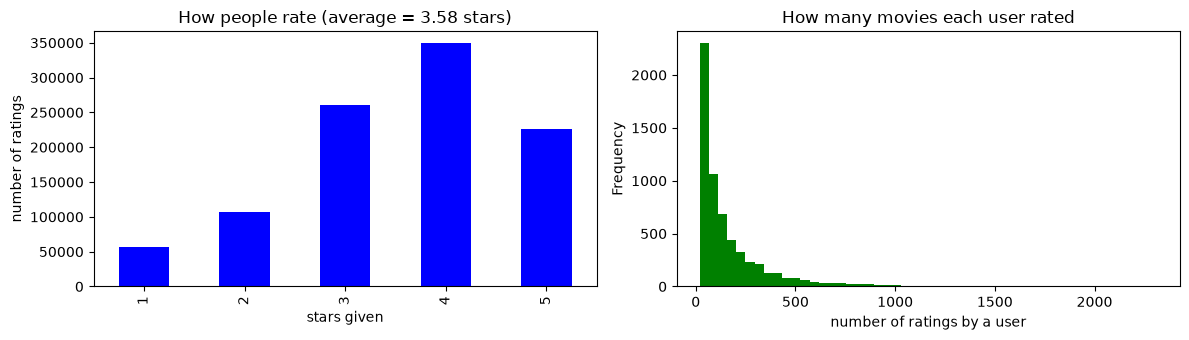

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

# Distribution of star ratings
ratings.rating.value_counts().sort_index().plot(kind="bar", ax=ax[0], color="blue")
ax[0].set_title(f"How people rate (average = {ratings.rating.mean():.2f} stars)")
ax[0].set_xlabel("stars given"); ax[0].set_ylabel("number of ratings")

# Derive number of ratings per user
ratings.groupby("userId").size().plot(kind="hist", bins=50, ax=ax[1], color="green")
ax[1].set_title("How many movies each user rated")
ax[1].set_xlabel("number of ratings by a user")
plt.tight_layout(); plt.show()

baseline = mean_squared_error(ratings.rating, np.full(len(ratings), ratings.rating.mean())) ** 0.5

From the above, two observations are particularly relevant: ratings are positively skewed and the user-item matrix is highly sparse.

## Model Selection and Feature Engineering

This exercise uses one classical machine learning model (Linear Regression) and one deep learning model (Multi-layer Perceptron) for comparison. The below sections detail feature engineering and data preparation for use with these models.

### Feature Engineering for the Linear Regression Model

The Linear Regression model requires each rating to be represented as a vector of numerical features. A small and interpretable set is adopted:

- **`user_avg`**: the mean rating historically given by the user.
- **`movie_avg`**: the mean rating historically received by the movie.
- **`gender`, `age`, `year`**: basic user demographics and the release year of the film.
- **Genre**: each genre is represented by its own binary column indicating whether the film belongs to that category. We will use multi-hot rather than one-hot encoding as a film can belong to several genres at once (for example, Animation, Children's, and Comedy).

The two average-based features are expected to be the most informative, since the historical mean of a user and of a movie jointly account for much of the variation in ratings.

In [38]:
GENRES = ["Action","Adventure","Animation","Children's","Comedy","Crime","Documentary","Drama",
          "Fantasy","Film-Noir","Horror","Musical","Mystery","Romance","Sci-Fi","Thriller","War","Western"]

# Pull the release year out of the title, e.g. "Toy Story (1995)" -> 1995
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)
movies["year"] = movies["year"].fillna(movies["year"].median())

# Multi-hot encode the genres
for g in GENRES:
    movies["g_" + g] = movies["genres"].str.contains(re.escape(g)).astype(int)
GENRE_COLS = ["g_" + g for g in GENRES]

# Join the three tables into one big table
data = ratings.merge(users, on="userId").merge(movies, on="movieId")
data["gender_M"] = (data["gender"] == "M").astype(int)

# Build the feature columns for rows_to_label
def add_features(train_rows, rows_to_label):
    global_avg = train_rows["rating"].mean()
    out = rows_to_label.copy()
    user_avg = train_rows.groupby("userId")["rating"].mean()
    movie_avg = train_rows.groupby("movieId")["rating"].mean()
    out["user_avg"]  = out["userId"].map(user_avg).fillna(global_avg)
    out["movie_avg"] = out["movieId"].map(movie_avg).fillna(global_avg)
    return out

FEATURES = ["user_avg", "movie_avg", "gender_M", "age", "year"] + GENRE_COLS
print(f"Number of features used: {len(FEATURES)}")

Number of features used: 23


### Index encoding for the Multi-Layer Perceptron model

The deep learning model does not use the engineered features described above. Instead, each user and each movie is assigned a contiguous integer index (0, 1, 2, and so on), which serves as a lookup key into the model's embedding tables.

In [39]:
# Give every user and movie a simple index number starting from 0
user_ids = {u: i for i, u in enumerate(data.userId.unique())}
movie_ids = {m: i for i, m in enumerate(data.movieId.unique())}
data["user_index"] = data.userId.map(user_ids)
data["movie_index"] = data.movieId.map(movie_ids)

N_USERS = len(user_ids)
N_MOVIES = len(movie_ids)
GLOBAL_MEAN = data.rating.mean()
print(f"{N_USERS} users and {N_MOVIES} movies, average rating {GLOBAL_MEAN:.2f}")

6040 users and 3706 movies, average rating 3.58


### Validation

We shall split the data into 2 main parts: one to train the model, with 90% data, and then keep the remaining 10% purely for testing.

With the training part of the data, we shall use 5-fold validation. In effect, we will split the data into 5 parts, train the model on 4 parts, and validate on the remaining part. We shall do 5 iterations. We will use mean error and standard deviation for the validation.

In [40]:
# Keep 10% completely aside for the final test. Use the other 90% for training and validation
dev_data, test_data = train_test_split(data, test_size=0.10, random_state=SEED)
dev_data = dev_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# We will use 5-fold validation
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"{len(dev_data)} ratings for training and validation, {len(test_data)} kept aside for the final test.")

900188 ratings for training and validation, 100021 kept aside for the final test.


## Classical Machine Learning: Linear Regression

The model predicts the rating as a weighted sum of the input features (like predicted rating = sum of weight * feature, and plus bias).

To ensure features fit within a comparable numerical range, we will standardise the values.

In [41]:
def evaluate_linear(train_rows, test_rows):
    # Build features, using just the training dataset (don't touch the test dataset)
    train_f = add_features(train_rows, train_rows)
    test_f  = add_features(train_rows, test_rows)
    
    # Scale features
    scaler = StandardScaler().fit(train_f[FEATURES])
    Xtr = scaler.transform(train_f[FEATURES])
    Xte = scaler.transform(test_f[FEATURES])
    
    # Train and predict
    model = LinearRegression().fit(Xtr, train_f["rating"])
    preds = np.clip(model.predict(Xte), 1, 5)
    rmse = mean_squared_error(test_f["rating"], preds) ** 0.5
    return rmse

linear_scores = []
for fold, (tr_idx, va_idx) in enumerate(kfold.split(dev_data), start=1): # we are doing 5-folds
    rmse = evaluate_linear(dev_data.iloc[tr_idx], dev_data.iloc[va_idx])
    linear_scores.append(rmse)
    print(f"  Fold {fold}: RMSE = {rmse:.4f}")

linear_scores = np.array(linear_scores)
print(f"\nLinear Regression cross-validation RMSE = {linear_scores.mean():.4f} (+/- {linear_scores.std():.4f})")

  Fold 1: RMSE = 0.9242
  Fold 2: RMSE = 0.9225
  Fold 3: RMSE = 0.9233
  Fold 4: RMSE = 0.9222
  Fold 5: RMSE = 0.9262

Linear Regression cross-validation RMSE = 0.9237 (+/- 0.0014)


  Fold 5: RMSE = 0.9262

Linear Regression cross-validation RMSE = 0.9237 (+/- 0.0014)


## Deep Learning: Multi-layer Perceptron

In deep learning scenario, the model first tries to interpret minor features/dimensions at first layer (in our case, this is like preference for a particular genre, and affinity to rate). Subsequently, within the hidden layers, these featuresa are then aggregated to learn higher level behaviours, finally producing a rating prediction in the output layer.

In [42]:
class MLPRecommender(nn.Module):
    # Some of the hyperparameters are intentionally random, we need to try combinations to identify values that work the best.
    # For example, we use embedding-size as 32, just to keep it large enough to accomodate all minor dimensions.
    def __init__(self, n_users, n_movies, embedding_size=32, hidden_sizes=(64, 32), dropout=0.2):
        super().__init__()
        # Each user and movie is represented by an embedding vector
        self.user_emb = nn.Embedding(n_users, embedding_size)
        self.movie_emb = nn.Embedding(n_movies, embedding_size)
        
        # A single bias value per user and per movie
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.tensor(GLOBAL_MEAN))
        
        # The multi-layer perceptron: concatenated embeddings -> hidden layers -> one output
        layers = []
        input_size = 2 * embedding_size
        for h in hidden_sizes:
            layers += [nn.Linear(input_size, h), nn.ReLU(), nn.Dropout(dropout)]
            input_size = h
        layers += [nn.Linear(input_size, 1)]
        self.mlp = nn.Sequential(*layers)
        
        # Initialise the embeddings with small random values and the biases at zero
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.movie_emb.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, u, m):
        x = torch.cat([self.user_emb(u), self.movie_emb(m)], dim=1)   # join the two embeddings
        out = self.mlp(x).squeeze(1)                                  # pass through the hidden layers
        return out + self.user_bias(u).squeeze(1) + self.movie_bias(m).squeeze(1) + self.global_bias

# We shall run for 30 iterations and stop if and when 3 iterations don't produce any improvements.
def train_mlp(train_rows, valid_rows, max_epochs=30, patience=3):
    torch.manual_seed(SEED)
    model = MLPRecommender(N_USERS, N_MOVIES)
    optimiser = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    u_tr = torch.tensor(train_rows.user_index.values)
    m_tr = torch.tensor(train_rows.movie_index.values)
    y_tr = torch.tensor(train_rows.rating.values, dtype=torch.float32)
    u_va = torch.tensor(valid_rows.user_index.values)
    m_va = torch.tensor(valid_rows.movie_index.values)

    best_rmse, best_state, waited, history = 99, None, 0, []
    batch_size = 8192
    for epoch in range(max_epochs):
        model.train()
        order = torch.randperm(len(u_tr))
        for i in range(0, len(u_tr), batch_size):
            b = order[i:i + batch_size]
            optimiser.zero_grad()
            loss = loss_fn(model(u_tr[b], m_tr[b]), y_tr[b])
            loss.backward()
            optimiser.step()
            
        # Measure the error on the validation rows
        model.eval()
        with torch.no_grad():
            preds = torch.clamp(model(u_va, m_va), 1, 5).numpy()
        rmse = mean_squared_error(valid_rows.rating.values, preds) ** 0.5
        history.append(rmse)
        
        # We will use early stopping for simplicity, stop if no improvement for patience epochs
        if rmse < best_rmse - 1e-4:
            best_rmse, best_state, waited = rmse, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            waited += 1
            if waited >= patience:
                break
                
    model.load_state_dict(best_state)
    
    return model, best_rmse, history

We will again use the 5-fold scheme to train and validate the this model also.

In [52]:
mlp_scores = []
for fold, (tr_idx, va_idx) in enumerate(kfold.split(dev_data), start=1):
    _, rmse, _ = train_mlp(dev_data.iloc[tr_idx], dev_data.iloc[va_idx])
    mlp_scores.append(rmse)
    print(f"  Fold {fold}: RMSE = {rmse:.4f}")

mlp_scores = np.array(mlp_scores)
print(f"\nMulti-Layer Perceptron cross-validation RMSE = {mlp_scores.mean():.4f} (+/- {mlp_scores.std():.4f})")

  Fold 1: RMSE = 0.8827
  Fold 2: RMSE = 0.8788
  Fold 3: RMSE = 0.8804
  Fold 4: RMSE = 0.8796
  Fold 5: RMSE = 0.8830

Multi-Layer Perceptron cross-validation RMSE = 0.8809 (+/- 0.0017)


  Fold 5: RMSE = 0.8830

Multi-Layer Perceptron cross-validation RMSE = 0.8809 (+/- 0.0017)


## Comparative Analysis

Validating the models against the test dataset (the 10% cut that we had kept aside earlier). We will calculate RMSE, MAE, R2.

In [53]:
# We will train on the entire test dataset, and generate predictions against the testing dataset
# linear regression model
train_f = add_features(dev_data, dev_data)
test_f  = add_features(dev_data, test_data)
scaler = StandardScaler().fit(train_f[FEATURES])
linear_final = LinearRegression().fit(scaler.transform(train_f[FEATURES]), train_f["rating"])
linear_test_pred = np.clip(linear_final.predict(scaler.transform(test_f[FEATURES])), 1, 5)

# Training multi-layer percpetron
mlp_train, mlp_valid = train_test_split(dev_data, test_size=0.10, random_state=SEED)
mlp_final, _, mlp_history = train_mlp(mlp_train, mlp_valid)
mlp_final.eval()
with torch.no_grad():
    mlp_test_pred = torch.clamp(
        mlp_final(torch.tensor(test_data.user_index.values),
                 torch.tensor(test_data.movie_index.values)), 1, 5).numpy()

#  Regression metrics on the test set (RMSE, MAE, R2)
y_test = test_data.rating.values
def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

linear_test_rmse, linear_test_mae, linear_test_r2 = regression_metrics(y_test, linear_test_pred)
mlp_test_rmse, mlp_test_mae, mlp_test_r2 = regression_metrics(y_test, mlp_test_pred)

print(f"Linear Regression    ->  RMSE: {linear_test_rmse:.4f}   MAE: {linear_test_mae:.4f}   R-squared: {linear_test_r2:.4f}")
print(f"Multi-Layer Perceptron ->  RMSE: {mlp_test_rmse:.4f}   MAE: {mlp_test_mae:.4f}   R-squared: {mlp_test_r2:.4f}")

Linear Regression    ->  RMSE: 0.9271   MAE: 0.7340   R-squared: 0.3105
Multi-Layer Perceptron ->  RMSE: 0.8815   MAE: 0.6918   R-squared: 0.3767


We will use NDCG@10 to measure how well the models do in ranking the items a user has rated highly above those he/she has rated poorly. It takes values between 0 and 1, with the higher valies indicating better ranking quality.

In [45]:
def ndcg_at_10(test_rows, predictions):
    tmp = test_rows[["userId", "rating"]].copy()
    tmp["pred"] = predictions
    scores = []
    for _, group in tmp.groupby("userId"):
        if len(group) < 2:           # need at least 2 movies to rank
            continue
        scores.append(ndcg_score([group["rating"].values], [group["pred"].values], k=10))
    return np.mean(scores)

linear_ndcg = ndcg_at_10(test_data, linear_test_pred)
mlp_ndcg = ndcg_at_10(test_data, mlp_test_pred)
print(f"NDCG@10  ->  Linear Regression: {linear_ndcg:.4f}   |   Multi-Layer Perceptron: {mlp_ndcg:.4f}")

NDCG@10  ->  Linear Regression: 0.9315   |   Multi-Layer Perceptron: 0.9379


Pretty print and graph the results.

,Model,CV RMSE,CV RMSE std,Test RMSE,Test MAE,Test R-squared,Test NDCG@10
0,Linear Regression (classical),0.9237,0.0014,0.9271,0.7340,0.3105,0.9315
1,Multi-Layer Perceptron (deep learning),0.8809,0.0017,0.8815,0.6918,0.3767,0.9379


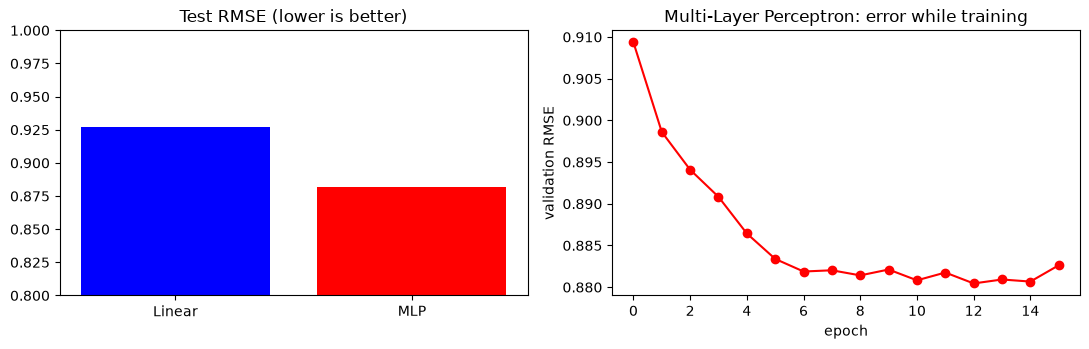

In [56]:
results = pd.DataFrame({
    "Model": ["Linear Regression (classical)", "Multi-Layer Perceptron (deep learning)"],
    "CV RMSE": [linear_scores.mean(), mlp_scores.mean()],
    "CV RMSE std": [linear_scores.std(), mlp_scores.std()],
    "Test RMSE": [linear_test_rmse, mlp_test_rmse],
    "Test MAE": [linear_test_mae, mlp_test_mae],
    "Test R-squared": [linear_test_r2, mlp_test_r2],
    "Test NDCG@10": [linear_ndcg, mlp_ndcg],
}).round(4)
display(results)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["Linear", "MLP"], [linear_test_rmse, mlp_test_rmse], color=["blue", "red"])
ax[0].set_title("Test RMSE (lower is better)"); ax[0].set_ylim(0.8, 1.0)
ax[1].plot(mlp_history, marker="o", color="red")
ax[1].set_title("Multi-Layer Perceptron: error while training")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation RMSE")
plt.tight_layout(); plt.show()

The deep learning model attains a lower RMSE and MAE and a higher R2 than the classical ML model, so the three regression metrics agree that it is the more accurate model. This outcome is consistent with expectation, as the former learns the taste of each individual user and movie directly from the ratings, whereas the latter relies on a small number of summary features. The learning curve shown on the right also illustrates the rationale for early stopping - the validation error decreases, reaches a minimum, and then begins to increase as the model starts to overfit; training is therefore terminated at the minimum.

With respect to NDCG@10, both models achieve high and comparable scores, because the dominant signal for ranking, namely the average quality of a movie, is accessible to both.

## Model Explainability

### Linear Regression
Because the model is a weighted sum, the coefficients can be used to explain the outcome. A large positive coefficient indicates that the corresponding feature increases the predicted rating. In addition, SHAP is applied to quantify the contribution of each feature to the predictions.

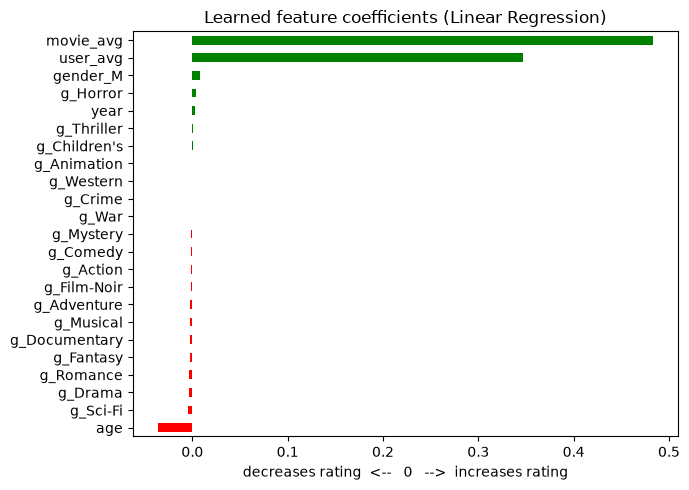

Two most influential features:
movie_avg    0.483752
user_avg     0.347356
dtype: float64


In [57]:
# The learned weights (with scaled features so these are directly comparable)
weights = pd.Series(linear_final.coef_, index=FEATURES).sort_values()
plt.figure(figsize=(7, 5))
weights.plot(kind="barh", color=["red" if w < 0 else "green" for w in weights])
plt.title("Learned feature coefficients (Linear Regression)")
plt.xlabel("decreases rating  <--   0   -->  increases rating")
plt.tight_layout(); plt.show()

print("Two most influential features:")
print(weights.abs().sort_values(ascending=False).head(2))

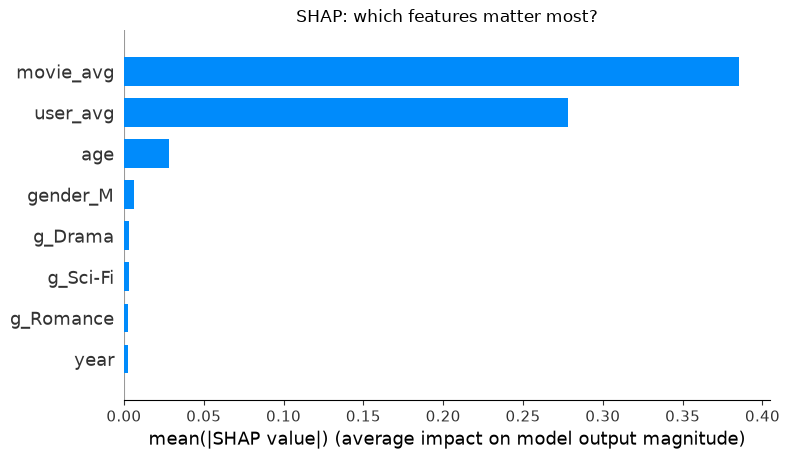

In [55]:
# SHAP: explain the predictions on a small sample of the test data.
# We use 100 rows as reference for thecomparison.
sample = scaler.transform(test_f[FEATURES].sample(1000, random_state=SEED))
background = scaler.transform(train_f[FEATURES].sample(100, random_state=SEED)) # taking 100 rows for comparison
explainer = shap.LinearExplainer(linear_final, background)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, features=sample, feature_names=FEATURES,
                  plot_type="bar", max_display=8, show=False)
plt.title("SHAP: which features matter most?"); plt.tight_layout(); plt.show()

### Multi-layer Perceptron

Deep learning models, by their nature, are difficult to explain. While a level of *understanding* of the model can be formed by analysing the input and output behaviours, the model still poses a challenge to provide reliable explanations. This aspect is covered in more detail within the presentation.